In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('TCS_stock_history.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,4463.000000,4463.000000,4463.000000,4463.000000,4.463000e+03,4463.000000,4463.000000
mean,866.936239,876.675013,856.653850,866.537398,3.537876e+06,0.071533,0.001344
std,829.905368,838.267104,821.233477,829.611313,3.273531e+06,0.965401,0.051842
min,24.146938,27.102587,24.146938,26.377609,0.000000e+00,0.000000,0.000000
25%,188.951782,191.571816,185.979417,188.594620,1.860959e+06,0.000000,0.000000
50%,530.907530,534.751639,525.616849,529.713257,2.757742e+06,0.000000,0.000000
75%,1156.462421,1165.815854,1143.622800,1154.784851,4.278625e+06,0.000000,0.000000
max,3930.000000,3981.750000,3892.100098,3954.550049,8.806715e+07,40.000000,2.000000


In [4]:
df['Diff'] = df['High']-df['Low']
df['Diff'].describe()

count    4463.000000
mean       20.021163
std        21.768259
min         0.000000
25%         5.977653
50%        12.823509
75%        26.040666
max       305.993129
Name: Diff, dtype: float64

In [5]:
df['MA20'] = df['Close'].rolling(20).mean()

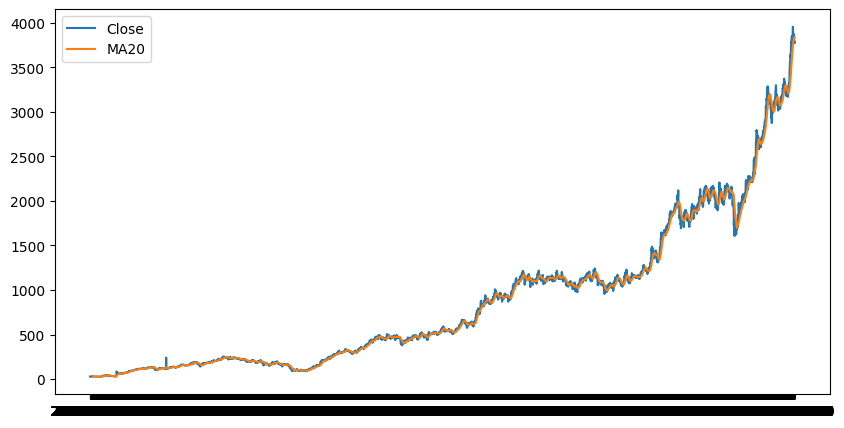

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['Close'], label = 'Close')
plt.plot(df['Date'],df['MA20'],label='MA20')
plt.legend()
plt.show()

In [8]:
df['MA50'] = df['Close'].rolling(50).mean()

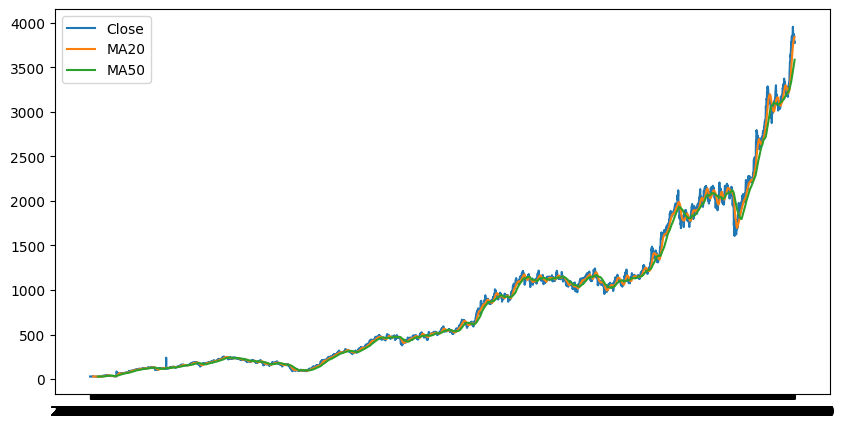

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['Close'],label = 'Close')
plt.plot(df['Date'],df['MA20'],label = 'MA20')
plt.plot(df['Date'],df['MA50'],label = 'MA50')
plt.legend()
plt.show()

In [10]:
df['Signal'] = 0
df.loc[df['MA20']>df['MA50'],'Signal'] = 1
df.loc[df['MA20']<df['MA50'],'Signal'] = -1

df[['Date','MA20','MA50','Signal']].tail(10)

,Date,MA20,MA50,Signal
4453,2021-09-17,3769.649988,3472.421836,1
4454,2021-09-20,3782.849988,3483.535469,1
4455,2021-09-21,3794.127490,3495.766382,1
4456,2021-09-22,3806.574988,3508.986104,1
4457,2021-09-23,3817.087488,3522.648169,1
4458,2021-09-24,3827.059985,3536.461992,1
4459,2021-09-27,3832.899988,3549.049990,1
4460,2021-09-28,3836.792480,3560.573989,1
4461,2021-09-29,3837.064978,3572.515986,1
4462,2021-09-30,3839.977478,3584.287983,1


In [11]:
df['Signal'].value_counts()

Signal
 1    2841
-1    1573
 0      49
Name: count, dtype: int64

In [14]:
df['Position'] = df['Signal'].diff()

In [15]:
df[['Date','Signal','Position']].tail(20)

,Date,Signal,Position
4443,2021-09-02,1,0.0
4444,2021-09-03,1,0.0
4445,2021-09-06,1,0.0
4446,2021-09-07,1,0.0
4447,2021-09-08,1,0.0
4448,2021-09-09,1,0.0
4449,2021-09-13,1,0.0
4450,2021-09-14,1,0.0
4451,2021-09-15,1,0.0
4452,2021-09-16,1,0.0


In [16]:
df[df['Position'] == 2].shape
df[df['Position'] == -2].shape

(52, 14)

In [17]:
buy = df[df['Position'] == 2]['Close']
sell = df[df['Position']   == -2]['Close']

profit = sell.values - buy.values[:len(sell)]

print("Total Profit:",profit.sum())

Total Profit: 960.6261100769045
